<a href="https://colab.research.google.com/github/lynnkaram/ai-course-projects/blob/main/project-1-llm-first-search/project1_ai_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Classic Search to LLM-First Search: A Self-Guided Exploration of the Solution Space 🚀

Hello everyone!

For this project, I chose to look at a paper that was published by three researchers - Nathan Herr, Tim Rocktäschel and Roberta Raileanu - in the Centre for AI at University College London, where I also completed my undergraduate studies :)

This paper was published on June 5, 2025. The link for the paper and its Github repository can be found at the very end of this tutorial (linked in references).

## Context: Reasoning as a Search Problem

Large Language Models (LLMs) have significantly improved their reasoning capabilities by framing problem-solving as a search process, analogous to human System 2 thinking (i.e the slower, effortful, deliberate, and analytical form of thought used for complex tasks, requiring conscious attention and significant cognitive resources). Techniques like Chain-of-Thought (CoT) enabled basic reasoning, but recent work leverages classic search algorithms:

*   **Breadth-First Search (BFS):** Used prominently in extensions like Tree-of-Thoughts (ToT-BFS). It explors many branches level-by-level, has good coverage but can be expensive.
*   **Best-First Search (BestFS):** Expands the most promising nodes greedily based on estimated value. It uses a simple heuristic to always expand the most promising state next.
*   **Monte Carlo Tree Search (MCTS):** Widely adopted and effective, often augmented with LLMs for world models and value estimators. It balances exploitation vs exploration using statistics from rollouts.

A key limitation of traditional MCTS, however, is its reliance on a fixed exploration constant C. This manual hyperparameter tuning limits adaptability, leading to over-exploration on simple tasks or under-exploration on harder problems. Re-tuning MCTS for new tasks, difficulty levels, or different base models is expensive and impractical.

## Introducing LLM-First Search (LFS)

**LLM-First Search (LFS)** is a novel, Self-Guided Search method proposed to overcome these limitations. LFS reimagines classical search by putting the LLM in direct control of the search process. Instead of relying on external heuristics or fixed exploration policies, the LLM itself autonomously decides whether to pursue the current path (exploit) or explore alternative branches. This removes the need for manually tuned exploration hyperparameters entirely.

This tight integration leads to more adaptive and efficient reasoning. Experiments show LFS achieving superior performance and greater efficiency compared to MCTS, BestFS, and ToT-BFS, especially as task difficulty increases . LFS also consistently constructs smaller or equal-sized search trees than MCTS, demonstrating efficient guided exploration.

## Visualization

The illustration below, taken directly from the paper, should help you understand the different search algorithms!

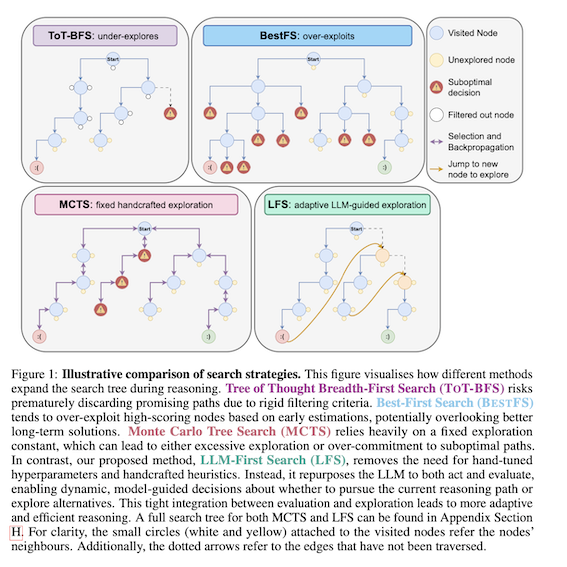

## Tutorial Goal: Understand BFS, BestFS, MCTS, and a toy LFS controller on a small numbers puzzle

**1. Start by adding all your imports**

In [ ]:
# You can run this using the Python standard library plus numpy and matplotlib.
import math
import random
import time
from collections import deque, defaultdict
import itertools
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

**2. Create the Countdown Environment**

Let's create a simple & small numbers game.

*   We start with a list of numbers (nums) and a target number (target).
*   One move = pick two numbers a and b, combine them with +, -, *, or / (if  exact), and replace a and b with the single result.
*   The goal is to reach the target exactly. If we don't reach it exactly, then we can just assume "closer is better".

In [ ]:
OPS = ["+", "-", "*", "/"]

# Define a function that returns True if a/b is an integer (no remainder) and b != 0
def valid_div(a, b):
    if b == 0:
        return False
    return (a % b) == 0

# Generate all results of combining a and b with +, -, *, / (integer-only for /)
def apply_ops(a, b):
    out = []
    out.append(("{}+{}={}".format(a, b, a + b), a + b))
    out.append(("{}-{}={}".format(a, b, a - b), a - b))
    out.append(("{}-{}={}".format(b, a, b - a), b - a))
    out.append(("{}*{}={}".format(a, b, a * b), a * b))
    if valid_div(a, b):
        out.append(("{}/{}={}".format(a, b, a // b), a // b))
    if valid_div(b, a):
        out.append(("{}/{}={}".format(b, a, b // a), b // a))
    return out

# Return all next states by combining any pair in nums
def next_states(nums):
    states = []
    n = len(nums)
    for i in range(n):
        for j in range(i + 1, n):
            a, b = nums[i], nums[j]
            rest = [nums[k] for k in range(n) if k not in (i, j)]
            for step_str, val in apply_ops(a, b):
                states.append((rest + [val], step_str))
    return states

# Finally, we design a simple heuristic, i.e. how close is our best number to the target. Again, lower is better
def distance_to_target(nums, target):
    best = min(abs(x - target) for x in nums)
    return best

# Goal check. This returns True if and only if the target number is already present in the current list of numbers
def is_goal(nums, target):
    return any(x == target for x in nums)


**3. Generate a Random Puzzle**

This next function creates a toy puzzle by generating a random list of numbers and a random target. This will later give the LLM a small, reproducible search problem to explore. You can run this cell repeatedly (or tweak list_len, max_val, and target_max) to generate new puzzles of varying difficulty for the LLM to explore.

In [ ]:
# Here I'm just generating a small random puzzle that's fast to search
def make_random_puzzle(list_len=4, max_val=20, target_max=40):
    nums = [random.randint(2, max_val) for _ in range(list_len)]
    target = random.randint(5, target_max)
    return nums, target

# Run an example. Tweak these values if you want to test different puzzles.
nums, target = make_random_puzzle(list_len=4, max_val=12, target_max=30)
print("Numbers:", nums, " Target:", target)


Numbers: [12, 3, 2, 6]  Target: 12


**4. Tree-of-Thoughts-Breadth First Search (ToT-BFS)**

Let's elaborate the Tree-of-Thoughts BFS idea a little more. The code below is a simplified version for you to learn the basics of it:)

Here, we explore the search tree level by level (breadth-first). We say breadth has has a width k. Each state is a partial “thought” (a partial arithmetic construction).

At each depth, we score states by a simple heuristic: distance_to_target(state) = min(|x - target| for x in state). The smaller the distance, the better / closer to goal.

Now, beam_k controls how many states survive per depth:
- beam_k = 1 -> keep only the single best state.     
- beam_k >= number_of_states_at_that_level -> keep all states.

An example: assume 8 states are produced at that level.
- beam_k=1  -> keep top 1
- beam_k=3  -> keep top 3
- beam_k>=8 -> keep all 8 (full breadth at this level)

We therefore keep only the top-k states each level, expand them, and stop if we hit target.

This “keep the best few partial thoughts and expand them” mimics ToT’s idea of reasoning over multiple promising partial solutions in parallel.

In [ ]:
def tot_bfs(nums, target, beam_k=10, max_nodes=500):
    # just some extra (maybe excessive) comments here to clarify certain concepts, as this part can be confusing at first glance.
    # basically, each frontier item is a tuple (current_numbers_list, path_of_strings)
    frontier = [(nums[:], [])]   # you start from a copy of nums and your path is empty (no moves yet)
    best = None                  # "best" is a placeholder variable for closest distance (it's not updated in this simplified version)
                                # it's a variable you create now to “hold a place” for a value you’ll compute or assign later.
                                # it starts with a special dummy value so the code has something to refer to, here we use "None"
                                # instead of 0 because 0 might actually be a distance!!
    nodes = 0                    # and "nodes" just counts how many states we've processed (so the work done)

    while frontier and nodes < max_nodes:
        # you score every state in the current level by its distance to the target
        scored = []
        for state_nums, path in frontier:
            nodes += 1
            if is_goal(state_nums, target):
                return {"solved": True, "path": path, "nodes": nodes, "best": 0}
            d = distance_to_target(state_nums, target)
            scored.append((d, state_nums, path))

        # then keep only the top-k closest states at this depth
        scored.sort(key=lambda x: x[0])
        frontier_next = []

        # and finally expand only the best 'beam_k' states into their children
        for _, state_nums, path in scored[:beam_k]:
            for next_nums, step in next_states(state_nums):
                frontier_next.append((next_nums, path + [step]))
        frontier = frontier_next

    return {"solved": False, "path": [], "nodes": nodes, "best": None}

You can tweak beam_k which controls how many states are kept at each level. Smaller values make the search faster and greedier, while larger values make it slower but more thorough.

You can also adjust max_nodes. Lower values may stop the search early, and higher values let you explore more.

Other things you can modify are the heuristic definition, the branching in next_states (adding or removing operations widens or narrows the search space and difficulty), etc.

**5. Best-First Search (simple heuristic)**

Best-First expands the "most promising" state first using a priority queue style.
We can simply use distance_to_target as the heuristic h(n).

In [ ]:
import heapq #python's built in priority-queue model

def best_first(nums, target, max_nodes=500):
    counter = 0
    start = (distance_to_target(nums, target), counter, nums[:], [])
    pq = [start]
    seen = set()
    nodes = 0

    def freeze(lst):
        return tuple(sorted(lst))

    while pq and nodes < max_nodes:
        score, _, cur, path = heapq.heappop(pq)
        nodes += 1
        if is_goal(cur, target):
            return {"solved": True, "path": path, "nodes": nodes, "best": 0}
        key = freeze(cur)
        if key in seen:
            continue
        seen.add(key)
        for nxt, step in next_states(cur):
            counter += 1
            h = distance_to_target(nxt, target)
            heapq.heappush(pq, (h, counter, nxt, path + [step]))

    return {"solved": False, "path": [], "nodes": nodes, "best": None}


**6. Monte Carlo Tree Search**

This is a tiny Monte Carlo Tree Search:
- Each node stores visits (N), total reward (W), and children.
- The Upper Confidence Bound (UCB) picks the child with the highest "value + exploration".
- A rollout is a few random steps guided by "closer to target".

Reward = 1 if solved during rollout, else something like 1 / (1 + distance).

In [ ]:
class Node:
    def __init__(self, nums, path):
        self.nums = nums[:]
        self.path = path[:]
        self.N = 0
        self.W = 0.0
        self.children = []
        self.is_expanded = False

# do a short random rollout and return a simple reward
def rollout_value(nums, target, max_steps=3):
    cur = nums[:]
    for _ in range(max_steps):
        if is_goal(cur, target):
            return 1.0
        moves = next_states(cur)
        if not moves:
            break
        moves.sort(key=lambda p: distance_to_target(p[0], target))
        k = min(3, len(moves))
        nxt, _ = moves[random.randint(0, k-1)]
        cur = nxt
    # if not solved, use a soft score based on closeness
    d = distance_to_target(cur, target)
    return 1.0 / (1.0 + d)

def ucb(child, parent_N, c=1.0):
    if child.N == 0:
        return float("inf")
    Q = child.W / child.N
    U = c * math.sqrt(math.log(parent_N + 1) / child.N)
    return Q + U

def mcts(nums, target, iters=200, c=1.0):
    root = Node(nums, [])
    for _ in range(iters):
        node = root
        path_stack = [node]
        while node.is_expanded and node.children:
            parent_N = node.N
            node = max(node.children, key=lambda ch: ucb(ch, parent_N, c))
            path_stack.append(node)

        if not node.is_expanded:
            node.is_expanded = True
            for nxt, step in next_states(node.nums):
                node.children.append(Node(nxt, node.path + [step]))
        reward = rollout_value(node.nums, target, max_steps=3)

        for nd in path_stack:
            nd.N += 1
            nd.W += reward

    # after search, pick the best child of root to report
    best = None
    if root.children:
        best = max(root.children, key=lambda ch: (ch.W / ch.N if ch.N else 0.0))
    solved = is_goal(nums, target) or (best and is_goal(best.nums, target))
    return {
        "solved": solved,
        "path": (best.path if best else []),
        "nodes": sum(ch.N for ch in (root.children or [])),
        "best": None
    }


**7. Toy LFS controller (self-guided continue vs explore)**

LFS (in the paper) lets the LLM decide whether to keep going deeper on the current path or to branch elsewhere. Here we simulate that controller with a more beginner-friendly rule:
- Track "improvement" in distance as we go deeper.
- If improvement is good recently, keep going deeper (exploit).
- If improvement stalls, branch to a different child (explore).

This captures the "self-guided" feel without necessarily calling an external model.

In [ ]:
def lfs_toy(nums, target, max_steps=40, stagnation_patience=2, branch_width=3):
    cur_nums = nums[:]
    path = []
    history = []
    last_d = distance_to_target(cur_nums, target)
    no_improve = 0

    for step in range(max_steps):
        if is_goal(cur_nums, target):
            return {"solved": True, "path": path, "nodes": step + 1, "best": 0}

        children = next_states(cur_nums)
        if not children:
            break

        # rank children by how much they improve distance
        scored = []
        for nxt, step_str in children:
            d = distance_to_target(nxt, target)
            gain = last_d - d
            scored.append((gain, nxt, step_str))
        scored.sort(key=lambda x: (-x[0], x[1]))  # best gain first

        # decide to either continue or explore
        if scored and scored[0][0] > 0:
            # improving child
            best_gain, best_nums, best_step = scored[0]
            cur_nums = best_nums
            path.append(best_step)
            history.append(best_gain)
            last_d = distance_to_target(cur_nums, target)
            no_improve = 0
        else:
            # no immediate improvement -> "explore"
            no_improve += 1
            candidates = scored[:branch_width] if scored else []
            if not candidates:
                break
            best_score = -1
            best_choice = None
            for _, nxt, step_str in candidates:
                score = 1.0 / (1.0 + distance_to_target(nxt, target))
                if score > best_score:
                    best_score = score
                    best_choice = (nxt, step_str)
            cur_nums, step_str = best_choice
            path.append(step_str)
            last_d = distance_to_target(cur_nums, target)

        # if we stagnate several moves, force a broader branch once
        if no_improve >= stagnation_patience:
            alt = scored[1:1+branch_width]
            if alt:
                cur_nums, step_str = alt[0][1], alt[0][2]
                path.append(step_str)
                last_d = distance_to_target(cur_nums, target)
                no_improve = 0

    return {"solved": False, "path": path, "nodes": len(path), "best": None}


**8. Single-puzzle demo 🎮**

Game timeeee!

In [ ]:
# Parameters + their definition. You can pretty much change all of these however you want and just re-run the code.
LIST_LEN   = 4     # number of starting numbers
MAX_VAL    = 12    # max value for a starting number
TARGET_MAX = 30    # max target value
BEAM_K     = 6     # ToT-BFS: how many states to keep per level
MAX_NODES  = 400   # ToT-BFS/BestFS: safety cap
MCTS_ITERS = 200   # MCTS: number of iterations
MCTS_C     = 1.0   # MCTS: exploration strength
LFS_STEPS  = 40    # toy LFS: max decision steps

nums, target = make_random_puzzle(LIST_LEN, MAX_VAL, TARGET_MAX)
print("Puzzle -> nums:", nums, " target:", target)

r1 = tot_bfs(nums, target, beam_k=BEAM_K, max_nodes=MAX_NODES)
r2 = best_first(nums, target, max_nodes=MAX_NODES)
r3 = mcts(nums, target, iters=MCTS_ITERS, c=MCTS_C)
r4 = lfs_toy(nums, target, max_steps=LFS_STEPS)

def show_result(name, r):
    print(f"{name:10s} | solved={r['solved']} | nodes≈{r['nodes']} | steps={len(r['path'])}")
    if r["path"]:
        print("  path:", " -> ".join(r["path"][:6]), ("..." if len(r["path"]) > 6 else ""))

show_result("ToT-BFS", r1)
show_result("BestFirst", r2)
show_result("MCTS", r3)
show_result("Toy-LFS", r4)


Puzzle -> nums: [5, 4, 3, 12]  target: 28
ToT-BFS    | solved=False | nodes≈128 | steps=0
BestFirst  | solved=True | nodes≈133 | steps=3
  path: 5-3=2 -> 12*2=24 -> 4+24=28 
MCTS       | solved=False | nodes≈199 | steps=1
  path: 12-5=7 
Toy-LFS    | solved=False | nodes≈3 | steps=3
  path: 5*4=20 -> 12+20=32 -> 32-3=29 


**9. Compare methods over many random puzzles**

For the first parameters, you can:
- Change n_games in run_batch. More games produce smoother, more reliable win-rate and avg-nodes estimates but take longer. Fewer games run faster but are noisier.
- Tune puzzle difficulty by editing LIST_LEN, MAX_VAL, and TARGET_MAX. Larger values usually make puzzles harder and spread methods apart.

For the rest:
- ToT-BFS/Best-First, raise or lower BEAM_K and MAX_NODES to trade thoroughness for speed. Higher values typically increase win rate but explore more nodes. Lower values are quicker and greedier and may miss solutions.
- For MCTS, increase MCTS_ITERS for better estimates (slower) and adjust MCTS_C to favor exploration (higher) or exploitation (lower).
- For the toy local forward search, increasing LFS_STEPS gives it more chances to solve at a time cost.

Now the code:

In [ ]:
def run_batch(n_games=20):
    results = {"tot": [], "best": [], "mcts": [], "lfs": []}
    for _ in range(n_games):
        nums, target = make_random_puzzle(LIST_LEN, MAX_VAL, TARGET_MAX)
        results["tot"].append(tot_bfs(nums, target, beam_k=BEAM_K, max_nodes=MAX_NODES))
        results["best"].append(best_first(nums, target, max_nodes=MAX_NODES))
        results["mcts"].append(mcts(nums, target, iters=MCTS_ITERS, c=MCTS_C))
        results["lfs"].append(lfs_toy(nums, target, max_steps=LFS_STEPS))
    return results

def summarize(batch):
    def winrate(lst):
        return 100.0 * np.mean([1 if r["solved"] else 0 for r in lst])
    def avg_nodes(lst):
        return float(np.mean([r["nodes"] for r in lst]))
    return {
        "ToT-BFS": (winrate(batch["tot"]), avg_nodes(batch["tot"])),
        "BestFS":  (winrate(batch["best"]), avg_nodes(batch["best"])),
        "MCTS":    (winrate(batch["mcts"]), avg_nodes(batch["mcts"])),
        "Toy-LFS": (winrate(batch["lfs"]), avg_nodes(batch["lfs"])),
    }

batch = run_batch(n_games=30)
summary = summarize(batch)
for name, (wr, an) in summary.items():
    print(f"{name:8s}  WinRate={wr:.1f}%   AvgNodes≈{an:.1f}")


ToT-BFS   WinRate=53.3%   AvgNodes≈74.4
BestFS    WinRate=80.0%   AvgNodes≈100.0
MCTS      WinRate=26.7%   AvgNodes≈199.0
Toy-LFS   WinRate=40.0%   AvgNodes≈2.9


**10. Simple bar charts (win rate and average nodes)**

For visualization ...

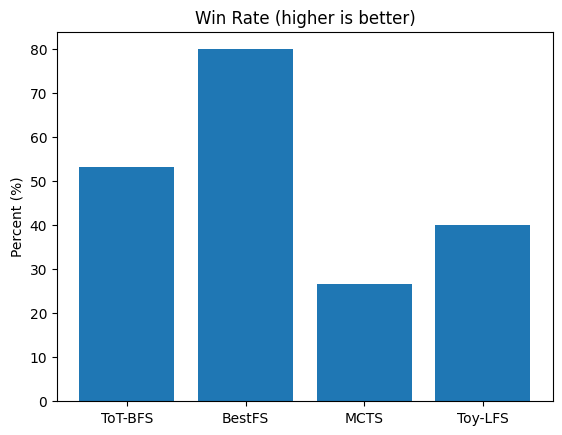

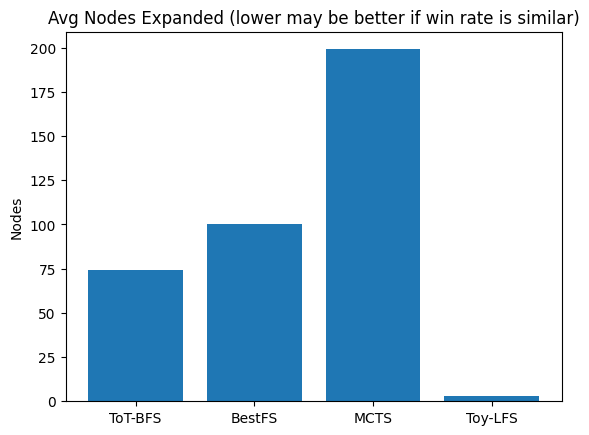

In [ ]:
names = list(summary.keys())
winrates = [summary[k][0] for k in names]
nodes    = [summary[k][1] for k in names]

plt.figure()
plt.title("Win Rate (higher is better)")
plt.bar(names, winrates)
plt.ylabel("Percent (%)")
plt.show()

plt.figure()
plt.title("Avg Nodes Expanded (lower may be better if win rate is similar)")
plt.bar(names, nodes)
plt.ylabel("Nodes")
plt.show()


**11. Inspect a single method’s path (step-by-step prints)**

To finish this tutorial, you can inspect a single run in detail. The cell below creates one random puzzle, runs the method you choose (i.e. one of either "tot", "best", "mcts", or "lfs"), and prints whether it solved the puzzle, roughly how many nodes it explored, and the exact sequence of moves it took.

This is for learning and debugging, it just helps you see why an algorithm made the choices it made!

In [ ]:
nums, target = make_random_puzzle(LIST_LEN, MAX_VAL, TARGET_MAX)
print("Example puzzle:", nums, "target:", target)

method = "lfs"  # but you can pick the method you want to check with

if method == "tot":
    result = tot_bfs(nums, target, beam_k=BEAM_K, max_nodes=MAX_NODES)
elif method == "best":
    result = best_first(nums, target, max_nodes=MAX_NODES)
elif method == "mcts":
    result = mcts(nums, target, iters=MCTS_ITERS, c=MCTS_C)
else:
    result = lfs_toy(nums, target, max_steps=LFS_STEPS)

print("Solved?", result["solved"])
print("Nodes visited (approx):", result["nodes"])
print("Steps taken:")
for s in result["path"]:
    print(" -", s)


Example puzzle: [5, 10, 8, 5] target: 11
Solved? False
Nodes visited (approx): 4
Steps taken:
 - 5-8=-3
 - 5*-3=-15
 - -3-5=-8
 - 10--8=18


## So guys, what did we learn? 🫱🏻‍🫲🏽

1) **Coverage vs Guidance**
- ToT-BFS spreads effort evenly across many branches, which improves coverage but can waste work on weak paths.
- Best-First greedily follows the state that looks closest under the heuristic, which works well when the heuristic truly tracks progress but can mislead when it doesn’t.

2) **Exploration vs Exploitation**
- MCTS uses the outcomes of its rollouts to balance exploitation (i.e favoring paths that currently look best) with exploration (i.e still trying less-visited paths in case they turn out better).

3) **Self-Guided Control (LFS flavor)**
- The toy LFS controller here decides to continue down a path when it keeps getting better and to branch when progress stalls.
- In the paper, an LLM plays this controller role, deciding when to extend a thought or try another (reducing the need for hand-tuned hyperparameters). This can yield higher win rates and better efficiency on harder puzzles like Countdown and Sudoku. (Check the repo’s method lineup and results.)  

4) **Takeaway**
- Framing reasoning as search lets us import classic search ideas.
- Letting a model govern when to continue vs. explore is a powerful way to use compute where it matters. This is the core LFS idea we demonstrated at small scale without any external APIs.




**References:**

[LLM-First Search: Self-Guided Exploration of the Solution Space](https://arxiv.org/abs/2506.05213)

[Github](https://github.com/NathanHerr/LLM-First-Search)